<a href="https://colab.research.google.com/github/niksio/neural_networks/blob/main/5.%20%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B%20%D0%A1%D0%9D%D0%A1%20%D0%B8%20Transfer%20Learning/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D0%9D%D0%A1_%D0%B8_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 1. Использование предобученной модели

### 1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/

In [1]:
import os
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    decode_predictions,
    preprocess_input,
    )


model = ResNet50(weights="imagenet")
INPUT_SIZE = (224, 224)
print("Модель загружена:", model.name)
print("Формат входа:", INPUT_SIZE)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Модель загружена: resnet50
Формат входа: (224, 224)


### 1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images

In [2]:
import requests

image_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg",
    "https://static.wikia.nocookie.net/nfs/images/f/f0/NFSUB_Garage_Ferrari_488GTB2016.jpg/revision/latest?cb=20230402170932&path-prefix=en",
    "https://upload.wikimedia.org/wikipedia/commons/8/8a/Banana-Single.jpg",
]

images_dir = Path("sample_images")
images_dir.mkdir(exist_ok=True)

images = []
image_paths = []

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

for i, url in enumerate(image_urls, start=1):
    file_path = images_dir / f"img_{i}.jpg"
    print(f"Downloading {url} to {file_path}")
    try:
        response = requests.get(url, headers=headers, stream=True)
        response.raise_for_status()
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        image_paths.append(str(file_path))
        images.append(np.array(Image.open(file_path).convert("RGB")))
        print(f"Successfully downloaded {url}")
    except requests.exceptions.RequestException as e:
        print(f"Failed to download {url}: {e}")
        continue

print(f"Загружено изображений: {len(images)}")
for p in image_paths:
    print(" -", p)


Successfully downloaded https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg
Successfully downloaded https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg
Successfully downloaded https://upload.wikimedia.org/wikipedia/commons/3/37/African_Bush_Elephant.jpg
Successfully downloaded https://static.wikia.nocookie.net/nfs/images/f/f0/NFSUB_Garage_Ferrari_488GTB2016.jpg/revision/latest?cb=20230402170932&path-prefix=en
Successfully downloaded https://upload.wikimedia.org/wikipedia/commons/8/8a/Banana-Single.jpg
Загружено изображений: 5
 - sample_images/img_1.jpg
 - sample_images/img_2.jpg
 - sample_images/img_3.jpg
 - sample_images/img_4.jpg
 - sample_images/img_5.jpg


### 1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [3]:
def preprocess_images_for_model(images_list, target_size=INPUT_SIZE):
    """
    Принимает список исходных изображений (np.ndarray) и возвращает
    независимый список предобработанных изображений под формат ResNet50.
    """
    images_copy = [img.copy() for img in images_list]

    processed = []
    for img in images_copy:
        pil_img = Image.fromarray(img).resize(target_size)
        arr = np.array(pil_img, dtype=np.float32)
        arr = preprocess_input(arr)
        processed.append(arr)

    return processed

processed_images = preprocess_images_for_model(images)
print("Количество предобработанных изображений:", len(processed_images))
print("Форма одного тензора:", processed_images[0].shape)

Количество предобработанных изображений: 5
Форма одного тензора: (224, 224, 3)


### 1.5. Выведите изображения и соответствующие им классы (как в примере из теории)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


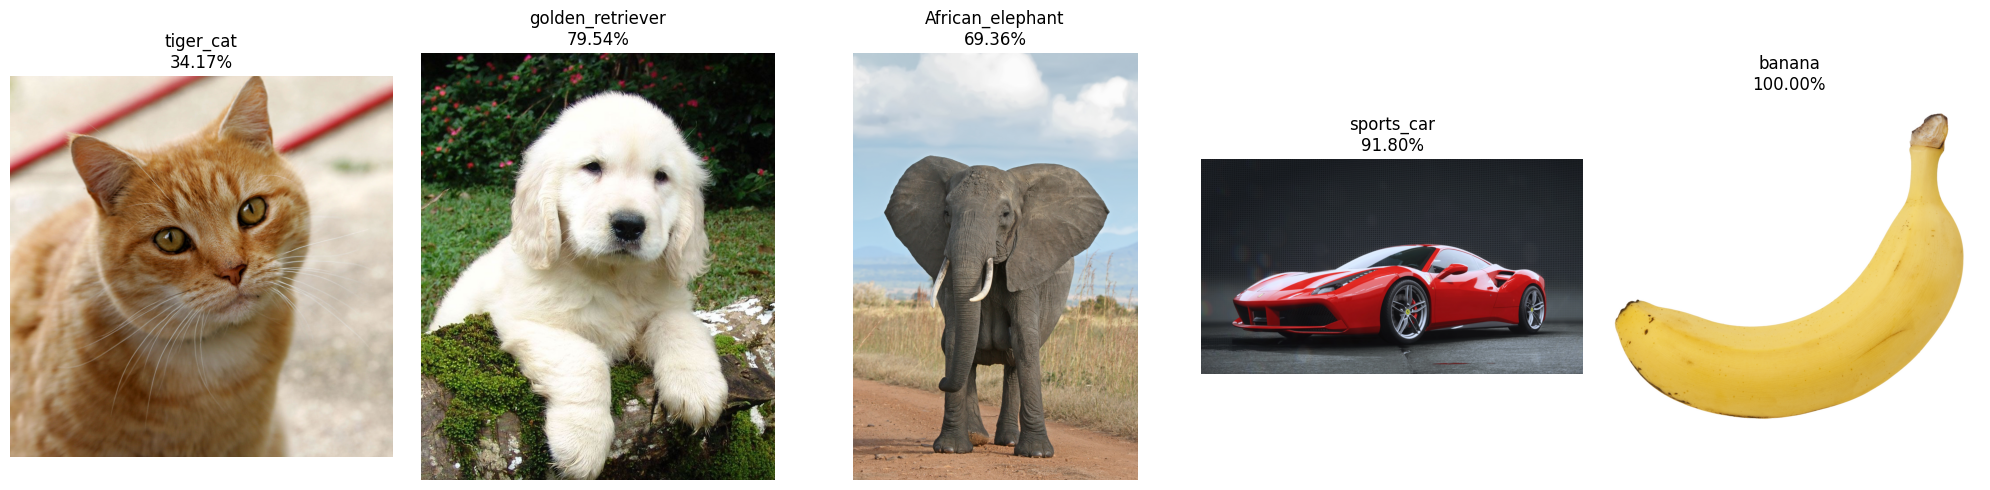

In [4]:
batch = np.stack(processed_images, axis=0)
preds = model.predict(batch, verbose=0)
decoded = decode_predictions(preds, top=1)

plt.figure(figsize=(20, 5))
for i, (img, pred) in enumerate(zip(images, decoded), start=1):
    class_name = pred[0][1]
    prob = pred[0][2]

    plt.subplot(1, len(images), i)
    plt.imshow(img)
    plt.title(f"{class_name}\n{prob:.2%}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Задание 2. Использование обученной модели для работы со своим датасетом

### 2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/

In [6]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input as mobilenet_preprocess_input,
    )

# Согласуем размер входа с данными из следующего шага
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

print("Выбрана модель:", base_model.name)
print("Размер входного тензора:", base_model.input_shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Выбрана модель: mobilenetv2_1.00_224
Размер входного тензора: (None, 224, 224, 3)


### 2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку

In [5]:
import os
import kagglehub

path = kagglehub.dataset_download("pavansanagapati/images-dataset")

print("Путь к датасету:", path)
custom_data_dir = path

print("Содержимое папки:", os.listdir(custom_data_dir))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

data_path = os.path.join(custom_data_dir, 'data')
if not os.path.exists(data_path):
    data_path = custom_data_dir

100%|██████████| 1.01G/1.01G [00:04<00:00, 238MB/s]

Extracting files...


Путь к датасету: /root/.cache/kagglehub/datasets/pavansanagapati/images-dataset/versions/1
Содержимое папки: ['data']


In [7]:
from pathlib import Path
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ИСПРАВЛЕНИЕ: Добавляем '/data' к пути, так как именно там лежат папки классов
dataset_dir = Path(custom_data_dir) / "data"

valid_classes = ['bike', 'cars', 'cats', 'dogs', 'flowers', 'horses', 'human']

print(f"Загрузка данных из: {dataset_dir}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=valid_classes
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=valid_classes
)

class_names = train_ds.class_names
num_classes = len(class_names)

val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_test_batches // 2)
test_ds = val_test_ds.skip(val_test_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("-" * 30)
print("Итоговые классы:", class_names)
print("Количество классов:", num_classes)

Загрузка данных из: /root/.cache/kagglehub/datasets/pavansanagapati/images-dataset/versions/1/data
Found 1803 files belonging to 7 classes.
Using 1443 files for training.
Found 1803 files belonging to 7 classes.
Using 360 files for validation.
------------------------------
Итоговые классы: ['bike', 'cars', 'cats', 'dogs', 'flowers', 'horses', 'human']
Количество классов: 7


### 2.3. Обучение своей модели на основе предобученной модели "*название модели, выбранной в п.2.1.*"

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 0. УБЕДИСЬ, ЧТО ЗАГРУЗИЛ ВЕСА IMAGENET
# base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

# 1. Усиливаем аугментацию
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Помогает смещать объект
])

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = mobilenet_preprocess_input(x)

# 2. Базовая модель
base_model.trainable = False
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x) # Снизили Dropout с 0.5 до 0.3
outputs = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = models.Model(inputs, outputs)

# 3. Callbacks (Умная остановка и понижение шага обучения)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# --- Этап 1: Обучение только головы ---
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("--- Этап 1: Обучение головы ---")
# Увеличь до 15-20 эпох. Благодаря EarlyStopping модель сама остановится, когда нужно.
history_initial = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Этап 2: Тонкая настройка (Размораживаем САМЫЙ КОНЕЦ) ---
base_model.trainable = True

total_layers = len(base_model.layers)
# Размораживаем 50 последних слоев
fine_tune_at = total_layers - 50

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Ставим очень маленький LR
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"\n--- Этап 2: Тонкая настройка (разморожено {total_layers - fine_tune_at} слоев) ---")
history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history_initial.epoch[-1] + 1,
    epochs=40, # Общее количество эпох
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

--- Этап 1: Обучение головы ---
Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.8323 - loss: 0.5119 - val_accuracy: 0.9688 - val_loss: 0.0997 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9494 - loss: 0.1458 - val_accuracy: 0.9844 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9626 - loss: 0.1127 - val_accuracy: 0.9896 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9716 - loss: 0.0839 - val_accuracy: 0.9896 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9667 - loss: 0.0937 - val_accuracy: 0.9896 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9730 - loss: 0.0763 - val_accuracy: 0.9844 - val_loss: 0.0433 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accurac

### 2.4. Визуализация процесса обучения модели

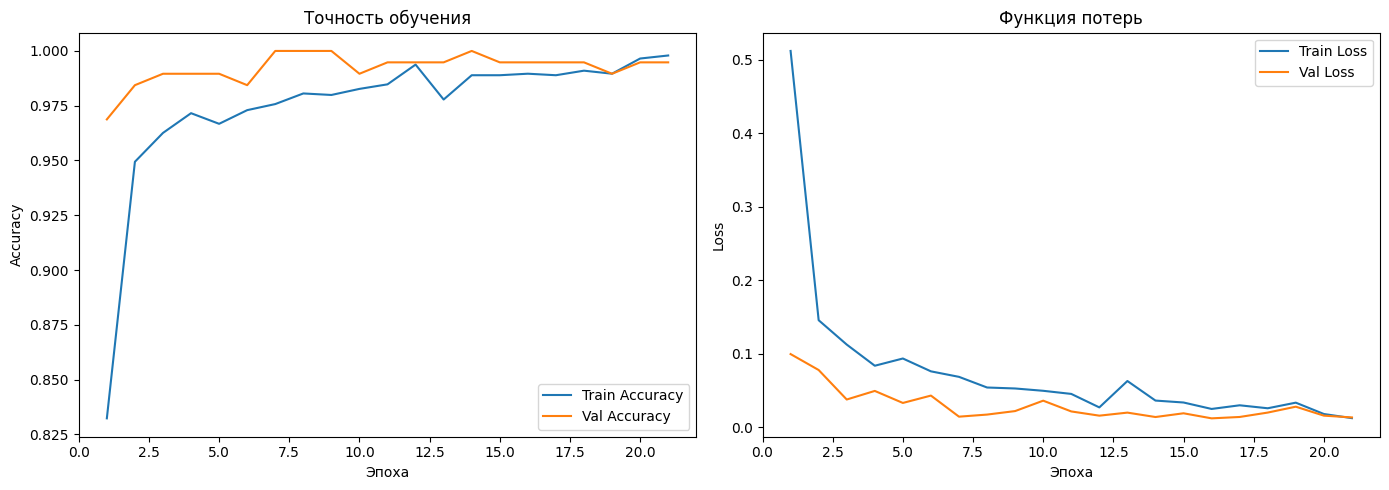

Итоговая точность на тестовой выборке: 1.0000


In [9]:
acc = history_initial.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history_initial.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history_initial.history["loss"] + history_fine.history["loss"]
val_loss = history_initial.history["val_loss"] + history_fine.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность обучения")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь")
plt.legend()

plt.tight_layout()
plt.show()

test_loss_t2, test_acc_t2 = transfer_model.evaluate(test_ds, verbose=0)
print(f"Итоговая точность на тестовой выборке: {test_acc_t2:.4f}")

### 2.5. Подготовьте набор проверочных данных (examples)

In [10]:
examples_dir = Path("gradio_examples")
examples_dir.mkdir(exist_ok=True)

examples = []
for i, img in enumerate(images, start=1):
    p = examples_dir / f"example_{i}.jpg"
    Image.fromarray(img).save(p)
    examples.append([str(p)])

print("Подготовлено примеров:", len(examples))
examples

Подготовлено примеров: 5


[['gradio_examples/example_1.jpg'],
 ['gradio_examples/example_2.jpg'],
 ['gradio_examples/example_3.jpg'],
 ['gradio_examples/example_4.jpg'],
 ['gradio_examples/example_5.jpg']]

### 2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow). В качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [11]:
import gradio as gr

def classify_flower(image):
    if image is None:
        return {name: 0.0 for name in class_names}

    img = Image.fromarray(image.astype(np.uint8)).convert("RGB").resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32)
    arr = np.expand_dims(arr, axis=0)
    # arr = mobilenet_preprocess_input(arr)

    pred = transfer_model.predict(arr, verbose=0)[0]
    return {name: float(score) for name, score in zip(class_names, pred)}

demo = gr.Interface(
    fn=classify_flower,
    inputs=gr.Image(type="numpy", label="Загрузите изображение"),
    outputs=gr.Label(num_top_classes=3, label="Предсказание модели"),
    examples=examples,
    title="Классификация цветов (Transfer Learning)",
    description="Модель MobileNetV2, дообученная на датасете.",
)

demo.launch(share=False, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [12]:
from google.colab import files

model_filename = "trained_model_mobilenetv2.keras"
transfer_model.save(model_filename)

print(f"Модель сохранена как {model_filename}")


files.download(model_filename)

Модель сохранена как trained_model_mobilenetv2.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Задание 3. Классификация набора пространственных данных EuroSat (для магистров)

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
from zipfile import ZipFile

# Путь для EuroSAT
eurosat_root = Path("EuroSAT")
zip_path = Path("EuroSAT.zip")

if not eurosat_root.exists():
    if not zip_path.exists():
        urlretrieve("https://madm.dfki.de/files/sentinel/EuroSAT.zip", zip_path)
    with ZipFile(zip_path, "r") as zf:
        zf.extractall(eurosat_root)

# В архиве обычно есть подпапка 2750
eurosat_data_dir = eurosat_root / "2750"
if not eurosat_data_dir.exists():
    eurosat_data_dir = eurosat_root

EURO_IMG_SIZE = (128, 128)
EURO_BATCH_SIZE = 32

train_ds_euro = tf.keras.utils.image_dataset_from_directory(
    eurosat_data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=EURO_IMG_SIZE,
    batch_size=EURO_BATCH_SIZE,
    )

val_test_ds_euro = tf.keras.utils.image_dataset_from_directory(
    eurosat_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=EURO_IMG_SIZE,
    batch_size=EURO_BATCH_SIZE,
    )

euro_classes = train_ds_euro.class_names
num_euro_classes = len(euro_classes)

val_test_batches_euro = tf.data.experimental.cardinality(val_test_ds_euro)
val_ds_euro = val_test_ds_euro.take(val_test_batches_euro // 2)
test_ds_euro = val_test_ds_euro.skip(val_test_batches_euro // 2)

train_ds_euro = train_ds_euro.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds_euro = val_ds_euro.cache().prefetch(AUTOTUNE)
test_ds_euro = test_ds_euro.cache().prefetch(AUTOTUNE)

print("Классы EuroSAT:", euro_classes)
print("Число классов:", num_euro_classes)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>

### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input

# Архитектура для задания 3: ResNet50
euro_base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=EURO_IMG_SIZE + (3,),
)
euro_base_model.trainable = False

print("Выбрана архитектура:", euro_base_model.name)

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
euro_inputs = layers.Input(shape=EURO_IMG_SIZE + (3,))
x = layers.RandomFlip("horizontal")(euro_inputs)
x = layers.RandomRotation(0.1)(x)
x = resnet_preprocess_input(x)
x = euro_base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
euro_outputs = layers.Dense(num_euro_classes, activation="softmax")(x)

euro_model = models.Model(euro_inputs, euro_outputs)
euro_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

epochs_euro = 5
history_euro = euro_model.fit(
    train_ds_euro,
    validation_data=val_ds_euro,
    epochs=epochs_euro,
    verbose=1,
    )



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



In [ ]:
import pandas as pd

# Оценка ResNet50
resnet_val_loss, resnet_val_acc = euro_model.evaluate(val_ds_euro, verbose=0)
resnet_test_loss, resnet_test_acc = euro_model.evaluate(test_ds_euro, verbose=0)

# Сравнение с MobileNetV2
mobile_base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=EURO_IMG_SIZE + (3,),
)
mobile_base.trainable = False

mobile_inputs = layers.Input(shape=EURO_IMG_SIZE + (3,))
y = layers.RandomFlip("horizontal")(mobile_inputs)
y = layers.RandomRotation(0.1)(y)
y = mobilenet_preprocess_input(y)
y = mobile_base(y, training=False)
y = layers.GlobalAveragePooling2D()(y)
y = layers.Dropout(0.3)(y)
mobile_outputs = layers.Dense(num_euro_classes, activation="softmax")(y)

mobile_model = models.Model(mobile_inputs, mobile_outputs)
mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Короткое обучение для сравнения архитектур
mobile_model.fit(
    train_ds_euro,
    validation_data=val_ds_euro,
    epochs=3,
    verbose=1,
    )

mobile_val_loss, mobile_val_acc = mobile_model.evaluate(val_ds_euro, verbose=0)
mobile_test_loss, mobile_test_acc = mobile_model.evaluate(test_ds_euro, verbose=0)

comparison_df = pd.DataFrame([
    {
        "Архитектура": "ResNet50",
        "Val Accuracy": resnet_val_acc,
        "Test Accuracy": resnet_test_acc,
        "Val Loss": resnet_val_loss,
        "Test Loss": resnet_test_loss,
    },
    {
        "Архитектура": "MobileNetV2",
        "Val Accuracy": mobile_val_acc,
        "Test Accuracy": mobile_test_acc,
        "Val Loss": mobile_val_loss,
        "Test Loss": mobile_test_loss,
    },
])

comparison_df

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------

В работе были решены три блока задач по применению архитектур CNN и transfer learning.

1. В задании 1 использована предобученная сеть ResNet50 (ImageNet):
- Загружены 5 изображений разных классов из интернета.
- Реализована функция предобработки входов под формат модели.
- Получены и визуализированы предсказания классов.

2. В задании 2 использовано дообучение MobileNetV2 на собственном датасете (flower_photos):
- Подготовлены обучающая, валидационная и тестовая выборки.
- Построена и обучена модель с этапом fine-tuning.
- Выполнена визуализация динамики accuracy/loss.
- Подготовлены examples и реализован интерфейс Gradio для интерактивной классификации изображений.

3. В задании 3 выполнена классификация EuroSAT:
- Загружен датасет, выполнено разбиение на train/val/test.
- Построена модель на базе ResNet50 и выполнено обучение.
- Проведена оценка на валидации и тесте.
- Выполнено сравнение с альтернативной архитектурой MobileNetV2.

Итог: transfer learning позволяет получить высокое качество при существенно меньших затратах времени и данных по сравнению с обучением сети с нуля. На результат заметно влияют размер входного изображения, количество эпох, batch size, скорость обучения и степень регуляризации (Dropout, аугментации). Для стабильного улучшения качества эффективен двухэтапный режим обучения: сначала обучение классификационной "головы", затем аккуратная тонкая настройка верхних слоев базовой сети с меньшим learning rate.